In [13]:
import json
import gzip
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

warnings.filterwarnings('ignore')

## Load Dataset from URL

In [15]:
REVIEW_URL  = 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/Musical_Instruments.jsonl.gz'
META_URL    = 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_Musical_Instruments.jsonl.gz'

DATA_DIR    = Path('../data/raw')
DATA_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_FILE = DATA_DIR / 'Musical_Instruments.jsonl.gz'
META_FILE   = DATA_DIR / 'meta_Musical_Instruments.jsonl.gz'

def download_if_missing(url, filename):
    if Path(filename).exists():
        print(f'  Already exists: {filename} ({Path(filename).stat().st_size/1e6:.1f} MB) — skipping.')
        return
    print(f'  Downloading {filename} ...')
    urllib.request.urlretrieve(url, filename)
    print(f'  Done: {filename} ({Path(filename).stat().st_size/1e6:.1f} MB)')

download_if_missing(REVIEW_URL, REVIEW_FILE)
download_if_missing(META_URL,   META_FILE)

  Done: ..\data\raw\Musical_Instruments.jsonl.gz (458.6 MB)
  Done: ..\data\raw\meta_Musical_Instruments.jsonl.gz (155.4 MB)


In [18]:
def load_jsonl_gz(filepath, max_rows=None):
    records = []
    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_rows and i >= max_rows:
                break
            records.append(json.loads(line.strip()))
    return pd.DataFrame(records)

print('Loading reviews...')
reviews = load_jsonl_gz(REVIEW_FILE)

print('Loading metadata...')
meta = load_jsonl_gz(META_FILE)

print(f'Reviews shape : {reviews.shape}')
print(f'Metadata shape: {meta.shape}')

Loading reviews...
Loading metadata...
Reviews shape : (3017439, 10)
Metadata shape: (213593, 16)


## Basic EDA of Dataset

In [25]:
# Basic EDA
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 3017439 entries, 0 to 3017438
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   rating             float64
 1   title              str    
 2   text               str    
 3   images             object 
 4   asin               str    
 5   parent_asin        str    
 6   user_id            str    
 7   timestamp          int64  
 8   helpful_vote       int64  
 9   verified_purchase  bool   
dtypes: bool(1), float64(1), int64(2), object(1), str(5)
memory usage: 210.1+ MB


In [ ]:
print(f"{meta.info()}")

<class 'pandas.DataFrame'>
RangeIndex: 213593 entries, 0 to 213592
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   main_category    210201 non-null  str    
 1   title            213593 non-null  str    
 2   average_rating   213593 non-null  float64
 3   rating_number    213593 non-null  int64  
 4   features         213593 non-null  object 
 5   description      213593 non-null  object 
 6   price            84916 non-null   object 
 7   images           213593 non-null  object 
 8   videos           213593 non-null  object 
 9   store            210037 non-null  str    
 10  categories       213593 non-null  object 
 11  details          213593 non-null  object 
 12  parent_asin      213593 non-null  str    
 13  bought_together  0 non-null       object 
 14  subtitle         338 non-null     str    
 15  author           121 non-null     object 
dtypes: float64(1), int64(1), object(9), str(5)
memory

In [23]:
reviews.head(2)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Five Stars,"Great headphones, comfortable and sound is goo...",[],B003LPTAYI,B003LPTAYI,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650586000,0,True
1,3.0,nice sound. pedal failed after less than 1 year,I like the piano.. but the sustain pedal faile...,[],B00723436A,B06XP6TDVY,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1558567365290,2,True


In [24]:
meta.head(2)

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Musical Instruments,Pearl Export Lacquer EXL725S/C249 5-Piece New ...,4.2,22,[Item may ship in more than one box and may ar...,[Introducing the best selling drum set of all ...,None,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Best Selling Drum Set of All Time'...,Pearl,"[Musical Instruments, Drums & Percussion, Drum...","{'Item Weight': '33 pounds', 'Product Dimensio...",B01M4HO6RK,None,NaN,NaN
1,Musical Instruments,Behringer EUROPOWER EPQ900 Professional 900 Wa...,4.0,13,[2 x 390 Watts into 4 Ohms; 2 x 245 Watts into...,"[BEHRINGER EUROPOWER EPQ900, Professional 900-...",None,[{'thumb': 'https://m.media-amazon.com/images/...,[],Behringer,"[Musical Instruments, Live Sound & Stage, Powe...","{'Item Weight': '10.8 pounds', 'Product Dimens...",B00508JFE4,None,NaN,NaN


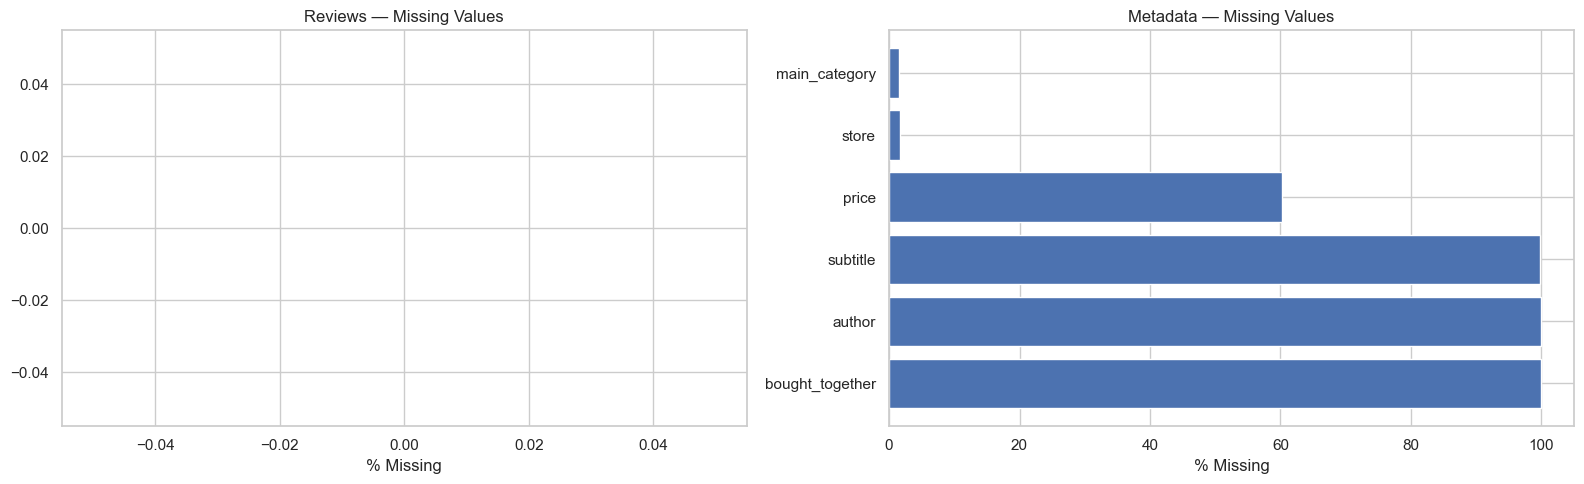

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, df, title in zip(axes, [reviews, meta], ['Reviews', 'Metadata']):
    missing = df.isnull().mean().sort_values(ascending=False) * 100
    missing = missing[missing > 0]
    ax.barh(missing.index, missing.values)
    ax.set_xlabel('% Missing')
    ax.set_title(f'{title} — Missing Values')

plt.tight_layout()
plt.show()

## Selection and Justification of fields for retrieval


Based on the possible fields, we decided to keep the following fields in the dataframe because they have the most semantically rich information that would be useful for querying. 

| File | Field | Type | Description |
|---|---|---|---|
| Review | `rating` | float | 1.0–5.0 star rating |
| Review | `title` | str | Review headline |
| Review | `text` | str | Full review body |
| Review | `parent_asin` | str | Parent product ID (use to join metadata) |
| Meta | `title` | str | Product name |
| Meta | `main_category` | str | Top-level category |
| Meta | `average_rating` | float | Aggregate product rating |
| Meta | `features` | list[str] | Bullet-point features |
| Meta | `description` | list[str] | Product description paragraphs |
| Meta | `store` | str | Seller / brand store name |
| Meta | `categories` | list[str] | Hierarchical category path |
| Meta | `details` | dict | Material, brand, dimensions, etc. |
| Meta | `parent_asin` | str | Join key to reviews |

In [27]:
# Select only the columns we need
reviews_slim = reviews[['rating', 'title', 'text', 'parent_asin']].copy()

meta_slim = meta[['parent_asin', 'title', 'main_category', 'average_rating',
                   'features', 'description', 'store', 'categories', 'details']].copy()

# Rename title columns before joining to avoid collision
reviews_slim = reviews_slim.rename(columns={'title': 'review_title'})
meta_slim    = meta_slim.rename(columns={'title': 'product_title'})

# Join on parent_asin
df = reviews_slim.merge(meta_slim, on='parent_asin', how='left')

print(df.shape)
print(df.columns.tolist())
df.head(2)

(3017439, 12)
['rating', 'review_title', 'text', 'parent_asin', 'product_title', 'main_category', 'average_rating', 'features', 'description', 'store', 'categories', 'details']


,rating,review_title,text,parent_asin,product_title,main_category,average_rating,features,description,store,categories,details
0,5.0,Five Stars,"Great headphones, comfortable and sound is goo...",B003LPTAYI,Sennheiser HD 202 II Professional Headphones (...,Home Audio & Theater,4.2,"[Ideal for DJ's and audio pros,Total harmonic ...","[Product Description, The Sennheiser HD202II a...",Sennheiser Consumer Audio,"[Musical Instruments, Pro & DJ Headphones]","{'Product Dimensions': '8 x 3 x 9.4 inches', '..."
1,3.0,nice sound. pedal failed after less than 1 year,I like the piano.. but the sustain pedal faile...,B06XP6TDVY,Korg SV-1BK 73-Key Stage Vintage Piano - Black,Musical Instruments,3.4,[73 keys; Korg's best RH3 Graded Hammer Action...,[The SV-1 has been captivating audiences since...,Korg,"[Musical Instruments, Keyboards & MIDI, Electr...","{'Item Weight': '38.5 pounds', 'Product Dimens..."
